In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [34]:
# SepalLengthCm – Długość działki kielicha.

# SepalWidthCm – Szerokość działki kielicha.

# PetalLengthCm – Długość płatka.

# PetalWidthCm – Szerokość płatka.

In [35]:
df = pd.read_csv('../data/Iris.csv')

### 1. EDA

In [36]:
print(f"Shape: {df.shape}")
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n--- Stats ---")
print(df.describe().T.round(2))
print("\n--- Column types ---")
print(df.dtypes.value_counts())

Shape: (150, 6)

--- Missing Values ---
Series([], dtype: int64)

--- Stats ---
               count   mean    std  min    25%    50%     75%    max
Id             150.0  75.50  43.45  1.0  38.25  75.50  112.75  150.0
SepalLengthCm  150.0   5.84   0.83  4.3   5.10   5.80    6.40    7.9
SepalWidthCm   150.0   3.05   0.43  2.0   2.80   3.00    3.30    4.4
PetalLengthCm  150.0   3.76   1.76  1.0   1.60   4.35    5.10    6.9
PetalWidthCm   150.0   1.20   0.76  0.1   0.30   1.30    1.80    2.5

--- Column types ---
float64    4
int64      1
str        1
Name: count, dtype: int64


In [37]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


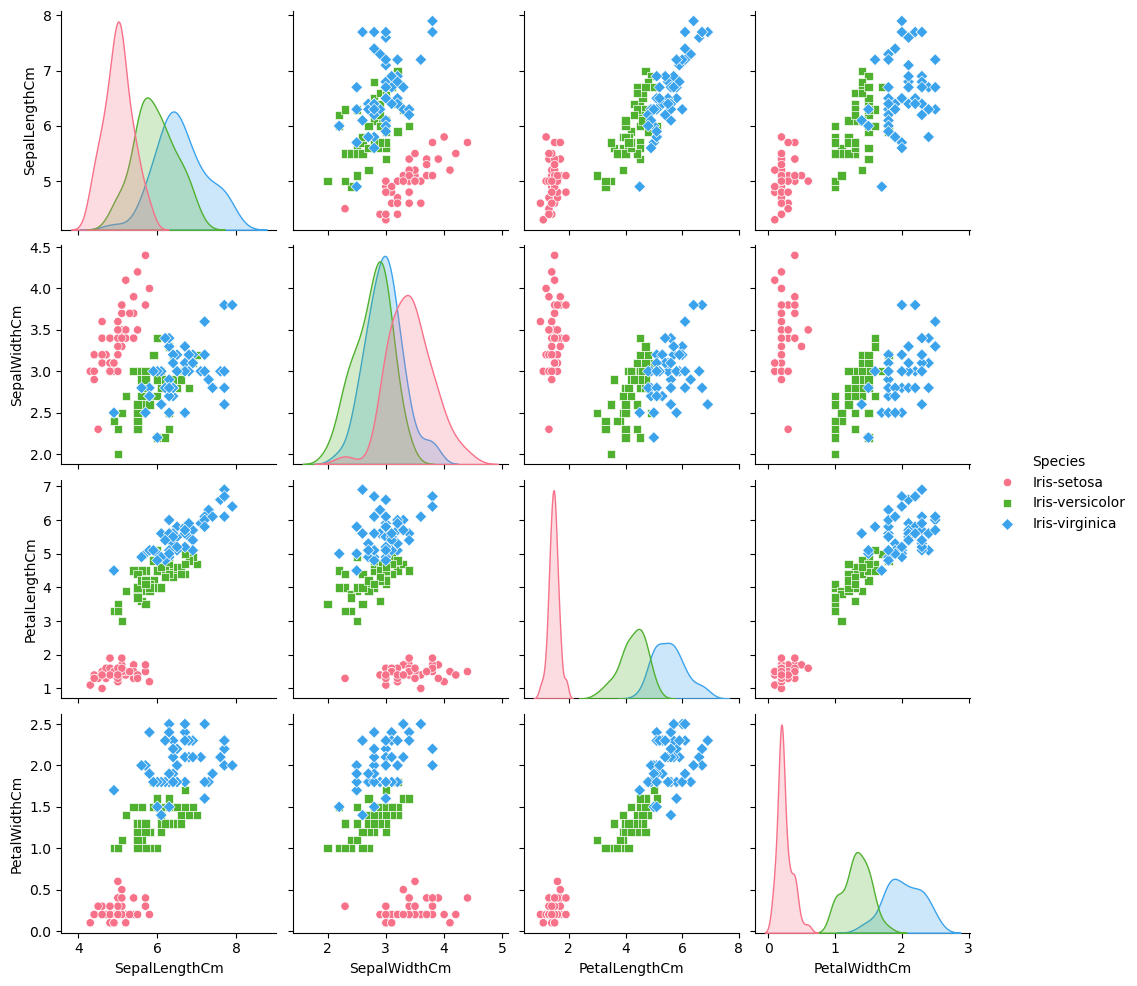

In [38]:
df_plot = df.drop('Id', axis=1)

sns.pairplot(df_plot, hue='Species', palette='husl', markers=["o", "s", "D"])
plt.show()

### TRAIN / TEST SPLIT

In [39]:
X = df.drop(['Id', 'Species'], axis = 1)
y = df['Species']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### MODEL

In [43]:
model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

In [44]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

### PREDICTION

In [46]:
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

### Accuracy

In [ ]:
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
print(f"Acc train: {acc_train:.4f}")
print(f"Acc test: {acc_test:.4f}")
# No overfitting  - more on tests than on train 

Acc train: 0.9500
Acc test: 0.9667


### CONF MATRIX

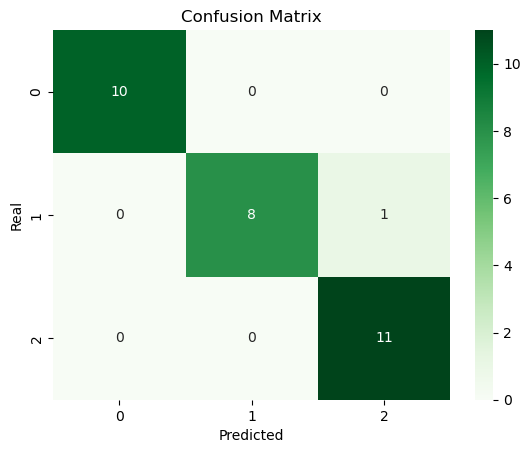

In [57]:
conf_matrx = confusion_matrix(y_test, y_test_pred)
sns.heatmap(conf_matrx, annot=True, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

### FEATURE IMPORTANCES

<Axes: ylabel='None'>

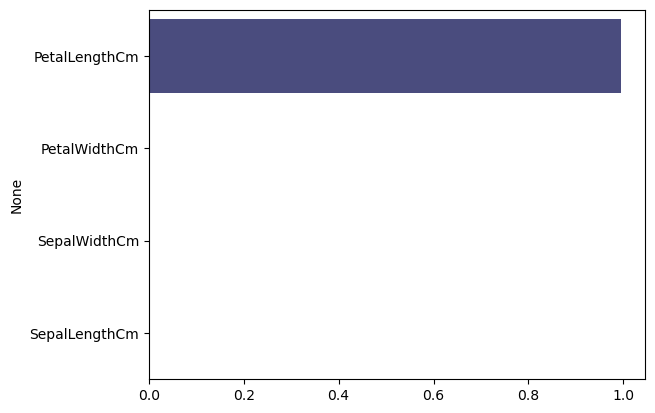

In [70]:
importances = model.feature_importances_
importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

sns.barplot(x=importances.values, y=importances.index,  hue=importances.index,  palette='viridis', legend=False)  


### TREE

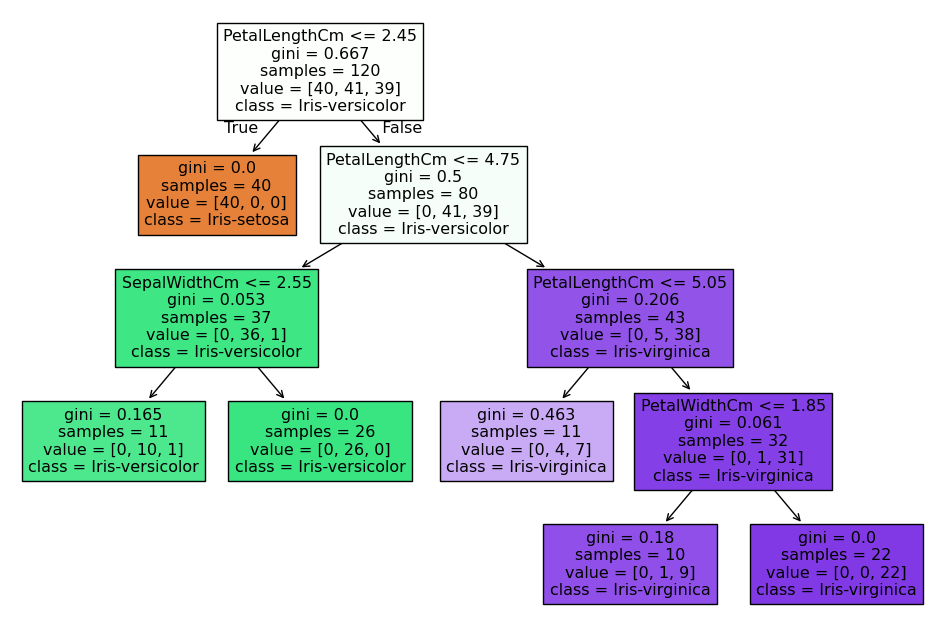

In [71]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()
